In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap, RealAmplitudes, EfficientSU2
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA, SPSA,ADAM
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import SamplerV2
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 150 
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 11 
plt.rcParams['svg.fonttype'] = 'none'

In [31]:
#def callback_graph(weights, obj_func_eval):
#    clear_output(wait=True)
#    objective_func_vals.append(obj_func_eval)
#    plt.title("Objective function value against Iteration")
#    plt.xlabel("Iteration")
#    plt.ylabel("Objective function value")
#    plt.plot(range(len(objective_func_vals)), objective_func_vals)
#    plt.show()
#

In [32]:
def callback_graph(*args):
    if len(args) == 2:
        obj_func_eval = args[1]
    elif len(args) == 5:
        obj_func_eval = args[2]
    else:
        return
    objective_func_vals.append(obj_func_eval)

In [33]:
file_path = 'pd_speech_features (1).csv'

In [ ]:
data = pd.read_csv(file_path, skiprows=1)
print(data.shape)
print(data.head())

(756, 755)
   id  gender      PPE      DFA     RPDE  numPulses  numPeriodsPulses  \
0   0       1  0.85247  0.71826  0.57227        240               239   
1   0       1  0.76686  0.69481  0.53966        234               233   
2   0       1  0.85083  0.67604  0.58982        232               231   
3   1       0  0.41121  0.79672  0.59257        178               177   
4   1       0  0.32790  0.79782  0.53028        236               235   

   meanPeriodPulses  stdDevPeriodPulses  locPctJitter  ...  \
0          0.008064            0.000087       0.00218  ...   
1          0.008258            0.000073       0.00195  ...   
2          0.008340            0.000060       0.00176  ...   
3          0.010858            0.000183       0.00419  ...   
4          0.008162            0.002669       0.00535  ...   

   tqwt_kurtosisValue_dec_28  tqwt_kurtosisValue_dec_29  \
0                     1.5620                     2.6445   
1                     1.5589                     3.6107   


In [35]:
X = data.drop(['id', 'class'], axis=1)
y = data['class'].values

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [37]:
#split into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

Train shape: (604, 753), Val shape: (152, 753)


In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)

In [39]:
##function to Train vqc with different configurations
def train_vqc(num_qubits, feature_map_type, ansatz_type, reps, optimizer_type, add_noise=False):
    #dimensionality reduction to num_qubits
    pca = PCA(n_components=num_qubits)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    #feature map
    if feature_map_type == 'ZZ':
        feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')
    elif feature_map_type == 'Z':
        feature_map = ZFeatureMap(feature_dimension=num_qubits, reps=2)

    # ansatz
    if ansatz_type == 'RealAmplitudes':
        ansatz = RealAmplitudes(num_qubits=num_qubits, reps=reps)
    elif ansatz_type == 'EfficientSU2':
        ansatz = EfficientSU2(num_qubits=num_qubits, reps=reps)

    # optimizer
    if optimizer_type == 'COBYLA':
        optimizer = COBYLA(maxiter=100)
    elif optimizer_type == 'SPSA':
        optimizer = SPSA(maxiter=100)
    elif optimizer_type == 'Adam':
        optimizer = ADAM(maxiter=100, lr=0.1)


    if add_noise:
        noise_model = NoiseModel()
        dep_error = depolarizing_error(0.01, 1)
        noise_model.add_all_qubit_quantum_error(dep_error, ['rx', 'ry', 'rz'])
        sampler = SamplerV2(options={"backend_options": {"noise_model": noise_model}})
    else:
        sampler = SamplerV2()

    # VQC
    global objective_func_vals
    objective_func_vals = []
    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=sampler,
        pass_manager=pass_manager,
        callback=callback_graph
    )

    vqc.fit(X_train_pca, y_train)
    y_pred = vqc.predict(X_val_pca)
    acc = accuracy_score(y_val, y_pred)

    qc = feature_map.compose(ansatz).decompose()
    num_params = ansatz.num_parameters
    depth = qc.depth()
    qubits = qc.num_qubits

    print(f"Config: Qubits={num_qubits}, FM={feature_map_type}, Ansatz={ansatz_type}, Reps={reps}, Opt={optimizer_type}, Noise={add_noise}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Parameters: {num_params}, Depth: {depth}, Qubits: {qubits}")

    return vqc, acc, num_params, depth, qubits, pca, objective_func_vals.copy()

In [40]:
configs = [
    (4, 'ZZ', 'RealAmplitudes', 6, 'SPSA', False),
    (6, 'ZZ', 'RealAmplitudes', 8, 'SPSA', False),
    (4, 'ZZ', 'EfficientSU2', 6, 'COBYLA', False),
    (4, 'Z', 'RealAmplitudes', 6, 'SPSA', False),
    (4, 'Z', 'RealAmplitudes', 8, 'SPSA', False),
    (4, 'Z', 'RealAmplitudes', 10, 'SPSA', False),
]

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [42]:
best_model = None
best_acc = 0
best_metrics = None
best_pca = None
all_histories = {}
results_list = []

for config in configs:
    model, acc, params, depth, qubits, pca, history = train_vqc(*config)
    label = f"Q{config[0]}-{config[1]}-{config[2]}-r{config[3]}-{config[4]}"
    all_histories[label] = history
    
    y_pred = model.predict(pca.transform(X_val))
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    results_list.append((config, acc, prec, rec, f1, params, depth))

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_metrics = (params, depth, qubits)
        best_pca = pca

print(f"Best Model Accuracy: {best_acc:.4f}")
print(f"Best Metrics: Parameters={best_metrics[0]}, Depth={best_metrics[1]}, Qubits={best_metrics[2]}")


C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:10: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')
C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:16: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=reps)


Config: Qubits=4, FM=ZZ, Ansatz=RealAmplitudes, Reps=6, Opt=SPSA, Noise=False
Accuracy: 0.6184
Parameters: 28, Depth: 39, Qubits: 4
Precision: 0.6114, Recall: 0.5789, F1: 0.5931


C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:10: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')
C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:16: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=reps)


Config: Qubits=6, FM=ZZ, Ansatz=RealAmplitudes, Reps=8, Opt=SPSA, Noise=False
Accuracy: 0.5526
Parameters: 54, Depth: 53, Qubits: 6
Precision: 0.6446, Recall: 0.5855, F1: 0.6071


C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:10: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')
C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:18: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=num_qubits, reps=reps)


...

Config: Qubits=4, FM=Z, Ansatz=RealAmplitudes, Reps=6, Opt=SPSA, Noise=False
Accuracy: 0.6908
Parameters: 28, Depth: 24, Qubits: 4
Precision: 0.6162, Recall: 0.6908, F1: 0.6404


C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:12: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_qubits, reps=2)
C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:16: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=reps)


Config: Qubits=4, FM=Z, Ansatz=RealAmplitudes, Reps=8, Opt=SPSA, Noise=False
Accuracy: 0.7105
Parameters: 36, Depth: 30, Qubits: 4
Precision: 0.5475, Recall: 0.7171, F1: 0.6209


C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:12: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=num_qubits, reps=2)
C:\Users\ronys\AppData\Local\Temp\ipykernel_30584\145375888.py:16: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=reps)


Config: Qubits=4, FM=Z, Ansatz=RealAmplitudes, Reps=10, Opt=SPSA, Noise=False
Accuracy: 0.6711
Parameters: 44, Depth: 36, Qubits: 4
Precision: 0.5407, Recall: 0.6842, F1: 0.6040
Best Model Accuracy: 0.7105
Best Metrics: Parameters=36, Depth=30, Qubits=4


In [43]:
def save_fig(name, fig=None):
    fig = fig or plt.gcf()
    fig.savefig(f"{name}.pdf", bbox_inches='tight')
    fig.savefig(f"{name}.svg", bbox_inches='tight')
    fig.savefig(f"{name}.png", dpi=600, bbox_inches='tight')

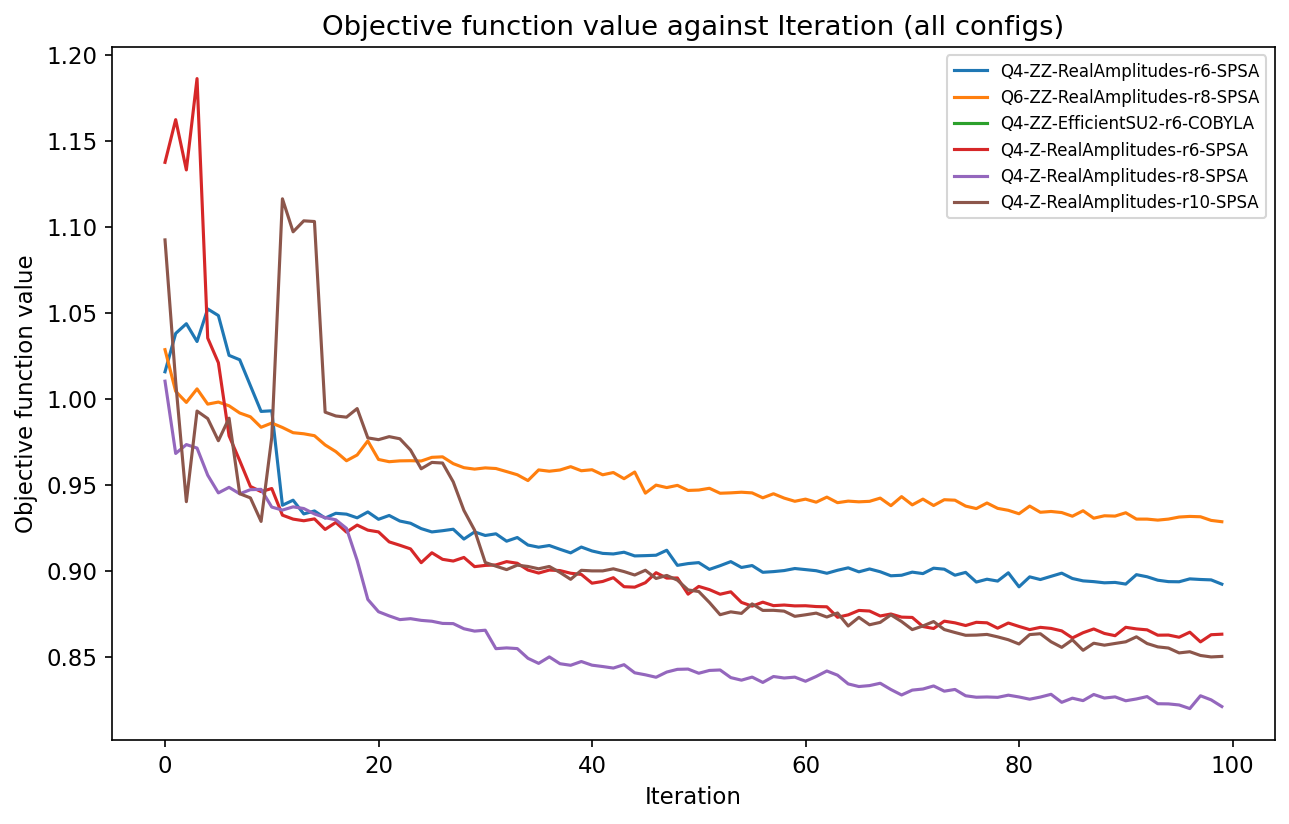

In [44]:
plt.figure(figsize=(10, 6))
for label, history in all_histories.items():
    plt.plot(range(len(history)), history, label=label)

plt.title("Objective function value against Iteration (all configs)")
plt.xlabel("Iteration")
plt.ylabel("Objective function value")
plt.legend(fontsize=8)
save_fig("convergence_all_configs")
plt.show()

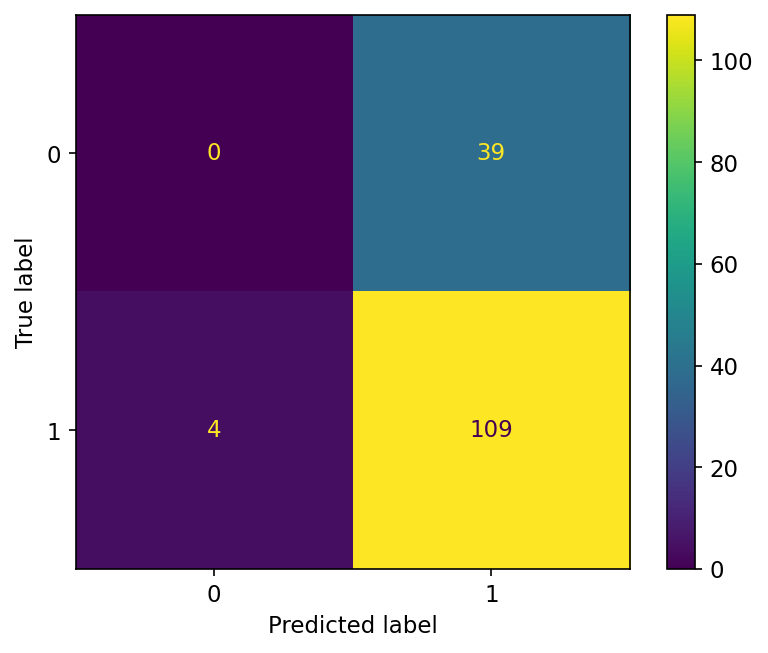

In [45]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(y_val, best_model.predict(best_pca.transform(X_val)))
save_fig("confusion_matrix", fig=disp.figure_)
plt.show()

In [46]:
# Circuit diagram — use mpl drawer, high-res PNG since PDF/SVG can occasionally render circuit glyphs oddly across Qiskit versions
fig = (best_model.feature_map.compose(best_model.ansatz)).decompose().draw("mpl", style="iqp")
save_fig("circuit_diagram", fig=fig)

In [48]:
results_df = pd.DataFrame([
    {"Qubits": c[0], "Feature Map": c[1], "Ansatz": c[2], "Reps": c[3],
     "Optimizer": c[4], "Noise": c[5], "Accuracy": acc, "Precision": prec,
     "Recall": rec, "F1": f1, "Params": params, "Depth": depth}
    for c, acc, prec, rec, f1, params, depth in results_list
])
print(results_df.to_latex(index=False, float_format="%.3f"))
print(results_df)

\begin{tabular}{rllrlrrrrrrr}
\toprule
Qubits & Feature Map & Ansatz & Reps & Optimizer & Noise & Accuracy & Precision & Recall & F1 & Params & Depth \\
\midrule
4 & ZZ & RealAmplitudes & 6 & SPSA & False & 0.618 & 0.611 & 0.579 & 0.593 & 28 & 39 \\
6 & ZZ & RealAmplitudes & 8 & SPSA & False & 0.553 & 0.645 & 0.586 & 0.607 & 54 & 53 \\
4 & ZZ & EfficientSU2 & 6 & COBYLA & False & 0.605 & 0.599 & 0.579 & 0.588 & 56 & 46 \\
4 & Z & RealAmplitudes & 6 & SPSA & False & 0.691 & 0.616 & 0.691 & 0.640 & 28 & 24 \\
4 & Z & RealAmplitudes & 8 & SPSA & False & 0.711 & 0.548 & 0.717 & 0.621 & 36 & 30 \\
4 & Z & RealAmplitudes & 10 & SPSA & False & 0.671 & 0.541 & 0.684 & 0.604 & 44 & 36 \\
\bottomrule
\end{tabular}

   Qubits Feature Map          Ansatz  Reps Optimizer  Noise  Accuracy  \
0       4          ZZ  RealAmplitudes     6      SPSA  False  0.618421   
1       6          ZZ  RealAmplitudes     8      SPSA  False  0.552632   
2       4          ZZ    EfficientSU2     6    COBYLA  False  0